In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# 1. Données du dataset (Heures d'étude et Notes finales)
heures_etude = np.array([2, 4, 3, 8, 10, 9, 3, 7]) # la matrice X
notes_finales = np.array([10, 10, 11, 15, 17, 18.5, 11, 16]) # le vecteur Y (Les cibles)

#     [2]           [10]
#     [4]           [10]
#     [3]           [11]
#     [8]           [15]
# x = [10]      y = [17]
#     [9]           [18.5]
#     [3]           [11]
#     [7]           [16]

In [9]:
# 2. Création de la matrice Y (Vecteur colonne)
Y = notes_finales.reshape(-1, 1)

In [10]:
# 3. Création de la matrice X
# On ajoute une colonne de 1 pour le biais (paramètre b)
#
#       [1, 2]
#       [1, 4]
#       [1, 3]
#       [1, 8]
# x =   [1, 10]
#       [1, 9]
#       [1, 3]
#       [1, 7]
# On peut faire cela en utilisant np.c_ pour concaténer une colonne de 1 avec la matrice des heures d'étude
m = len(heures_etude)
X_b = np.c_[np.ones((m, 1)), heures_etude]

In [11]:
print("Matrice X (avec biais) :\n", X_b) # affichage de la matrice X
print("\nVecteur Y :\n", Y) # affichage du vecteur Y

Matrice X (avec biais) :
 [[ 1.  2.]
 [ 1.  4.]
 [ 1.  3.]
 [ 1.  8.]
 [ 1. 10.]
 [ 1.  9.]
 [ 1.  3.]
 [ 1.  7.]]

Vecteur Y :
 [[10. ]
 [10. ]
 [11. ]
 [15. ]
 [17. ]
 [18.5]
 [11. ]
 [16. ]]


In [12]:
# 4. Calcul des paramètres (w) en utilisant la formule normale : W = (X^T * X)^(-1) * X^T * Y
#Calcul de l'Équation Normale
# Étape 1 : Calcul de la transposée X^T
XT = X_b.T

# Étape 2 : Calcul de (X^T * X)
XTX = XT.dot(X_b)

# Étape 3 : Calcul de l'inverse (X^T * X)^-1
XTX_inv = np.linalg.inv(XTX)

# Étape 4 : Calcul final W = (Inverse) * XT * Y
W = XTX_inv.dot(XT).dot(Y)

# Extraction des coefficients
b = W[0][0]
a = W[1][0]

print(f"Résultat du modèle : f(x) = {a:.2f} * x + {b:.2f}")

Résultat du modèle : f(x) = 1.05 * x + 7.55


In [13]:
# 4. Calcul des paramètres (w) en utilisant la formule normale : W = (X^T * X)^(-1) * X^T * Y
# modele plus compact
w= np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)
print(f"Résultat du modèle : f(x) = {w[1][0]:.2f} * x + {w[0][0]:.2f}")

Résultat du modèle : f(x) = 1.05 * x + 7.55


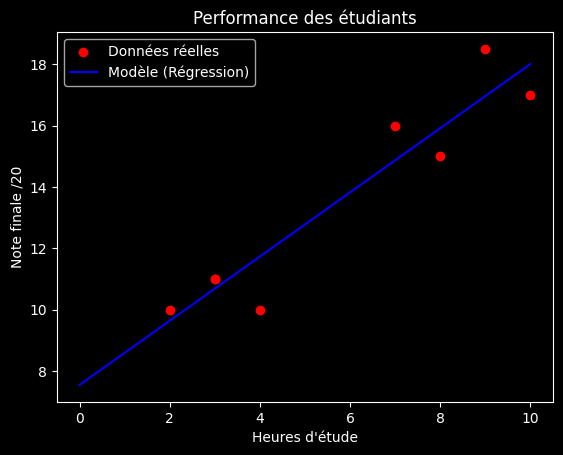

In [14]:
# Points réels du dataset
plt.scatter(heures_etude, notes_finales, color='red', label='Données réelles')

# Droite de prédiction
X_new = np.array([[0], [10]]) # Pour tracer la ligne de 0 à 10 heures
X_new_b = np.c_[np.ones((2, 1)), X_new] # Ajouter la colonne de 1 pour le biais
y_predict = X_new_b.dot(W) # Prédictions pour les nouvelles données

plt.plot(X_new, y_predict, "b-", label="Modèle (Régression)") # Tracer la ligne de régression
plt.xlabel("Heures d'étude") # affichage de l'axe des x
plt.ylabel("Note finale /20") # affichage de l'axe des y
plt.legend() # affichage de la légende
plt.title("Performance des étudiants") # affichage du titre du graphique
plt.show() # affichage du graphique

La note prédite pour 15.26h est : 23.51/20


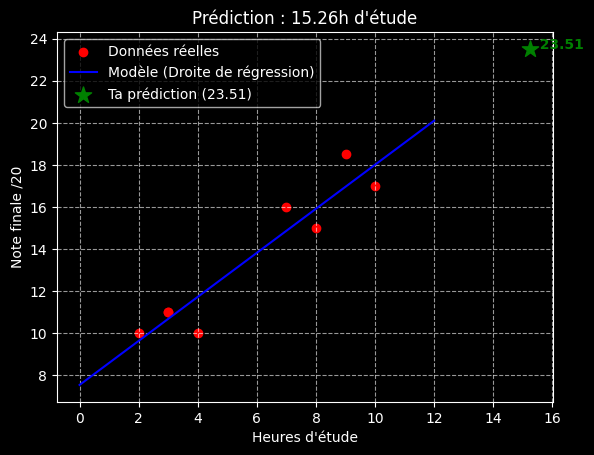

In [18]:
# --- 1. SAISIE MANUELLE ---
x_manuel = float(input("Entrez le nombre d'heures d'étude pour la prédiction : "))

# Calcul de la prédiction matricielle pour ce point précis
X_point = np.array([[1, x_manuel]]) # [1, x] pour le biais et la valeur
y_manuel = X_point.dot(W)[0][0]

print(f"La note prédite pour {x_manuel}h est : {y_manuel:.2f}/20")

# --- 2. VISUALISATION ---

# Points réels du dataset (en rouge)
plt.scatter(heures_etude, notes_finales, color='red', label='Données réelles')

# Tracer la droite de régression (en bleu)
X_ligne = np.array([[0], [12]]) # On trace de 0 à 12h pour couvrir le graphique
X_ligne_b = np.c_[np.ones((2, 1)), X_ligne]
y_ligne_predict = X_ligne_b.dot(W)
plt.plot(X_ligne, y_ligne_predict, "b-", label="Modèle (Droite de régression)")

# AJOUT DU POINT MANUEL (en vert avec une étoile pour bien le voir)
plt.scatter(x_manuel, y_manuel, color='green', s=150, marker='*', label=f'Ta prédiction ({y_manuel:.2f})')

# Annoter le point pour plus de clarté
plt.annotate(f"  {y_manuel:.2f}", (x_manuel, y_manuel), color='green', fontweight='bold')

# Configuration du graphique
plt.xlabel("Heures d'étude")
plt.ylabel("Note finale /20")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6) # Ajout d'une grille pour mieux lire
plt.title(f"Prédiction : {x_manuel}h d'étude")
plt.show()